# Проект: Исследование стартапов

## Введение

## Цели и задачи проекта

**Цель**: Подготовить и исследовать данные о стартапах, чтобы проверить их корректность и выявить факторы, влияющие на успешность сделок по покупке компаний.

**Задачи**:

1. Загрузить данные и ознакомиться с их структурой.

2. Провести предобработку данных.

3. Определить ключевые столбцы для объединения информации из разных таблиц.

4. Проверить достоверность данных о сотрудниках стартапов и их образовании.

5. Проанализировать значения покупок за 0 и 1 доллар и дать их интерпретацию.

6. Исследовать взаимосвязь между количеством раундов финансирования, категорией стартапов и ценой их покупки.

7. Рассчитать и визуализировать ключевые показатели и динамику изменений.

8. Сформулировать выводы и выделить признаки, указывающие на повышенную вероятность успешной сделки.


## Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv  
* investment.csv


Они находятся в папке datasets, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### Вывод общей информации, исправление названия столбцов

- Загрузите все данные по проекту.
- Проверьте названия столбцов.
- Выведите информацию, которая необходима вам для принятия решений о предобработке, для каждого из датасетов.

In [1]:
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные
PATH = "https://code.s3.yandex.net/datasets/"

acquisition = pd.read_csv(PATH + 'acquisition.csv')
company_and_rounds = pd.read_csv(PATH + 'company_and_rounds.csv')
people = pd.read_csv(PATH + 'people.csv')
education = pd.read_csv(PATH + 'education.csv')
degrees = pd.read_csv(PATH + 'degrees.csv')

Далее, знакомимся с данными.

In [4]:
display(acquisition.head())
print()
acquisition.info()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [5]:
display(company_and_rounds.head())
print()
company_and_rounds.info()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nu

In [6]:
display(people.head())
print()
people.info()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [7]:
display(education.head())
print()
education.info()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [8]:
display(degrees.head())
print()
degrees.info()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


### Промежуточный вывод

Всего было загружено пять таблиц:

 - `acquisition`: 6 столбцов, 9407 строк.

 - `company_and_rounds`: 22 столбца, 217 774 строки.

 - `people`: 5 столбцов, 226 709 строк.

 - `education`: 4 столбца, 109 610 строк.

 - `degrees`: 4 столбца, 109 610 строк.

Что заметно сразу:

 - Привести заголовки к `snake_case`;
  
 - В `company_and_rounds` слить дубли `company id/company ID` в `company_id`

 - В `degrees.object_id` убрать префикс `p:` и привести к целому для присоединения по `people.id`.

 - Преобразовать типы данных, где необходимо (даты, числовые, целочисленные). Помимо этого, заметны критически пропуски, которые также необходимо обработать.

### Смена типов и анализ пропусков

- Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.
- Оцените полноту данных — сделайте предварительный вывод, достаточно ли данных для решения задач проекта.

In [ ]:
# Нормализация имён колонок в company_and_rounds 

company_and_rounds.columns = company_and_rounds.columns.str.lower().str.replace(r'\s+', '_', regex=True)

In [10]:
# После rename остались два столбца company_id, берём первый непустой:

if 'company_id' in company_and_rounds.columns:
    dup_cols = [c for c in company_and_rounds.columns if c == 'company_id']
    if len(dup_cols) > 1:
        merged = company_and_rounds[dup_cols].bfill(axis=1).iloc[:, 0]
        company_and_rounds = company_and_rounds.drop(columns=dup_cols).assign(company_id=merged)

In [11]:
# Приведение типов в acquisition

acquisition['acquired_at'] = pd.to_datetime(acquisition['acquired_at'], errors='coerce')

for col in ['id', 'acquiring_company_id', 'acquired_company_id', 'price_amount']:
    acquisition[col] = pd.to_numeric(acquisition[col], errors='coerce').astype('Int64')
    
acquisition['term_code'] = acquisition['term_code'].astype('category')

In [12]:
# Приведение типов в company_and_rounds

for col in ['founded_at', 'closed_at', 'funded_at']:
    if col in company_and_rounds.columns:
        company_and_rounds[col] = pd.to_datetime(company_and_rounds[col], errors='coerce')
        
for col in ['company_id', 'investment_rounds', 'funding_rounds', 'funding_round_id', 'participants', 'is_first_round']:
    if col in company_and_rounds.columns:
        company_and_rounds[col] = pd.to_numeric(company_and_rounds[col], errors='coerce').astype('Int64')

for col in ['funding_total', 'raised_amount', 'pre_money_valuation']:
    if col in company_and_rounds.columns:
        company_and_rounds[col] = pd.to_numeric(company_and_rounds[col], errors='coerce')

for col in ['status', 'category_code', 'country_code', 'funding_round_type']:
    if col in company_and_rounds.columns:
        company_and_rounds[col] = company_and_rounds[col].astype('category')

In [13]:
# Приведение типов в people 

people['id'] = people['id'].astype('Int64')

if 'company_id' in people.columns:
    people['company_id'] = pd.to_numeric(people['company_id'], errors='coerce').astype('Int64')

In [14]:
# Приведение типов в education 

education['id'] = education['id'].astype('Int64')

education['person_id'] = education['person_id'].astype('Int64')

education['graduated_at'] = pd.to_datetime(education['graduated_at'], errors='coerce')

In [15]:
# Приведение типов в degrees 

degrees['id'] = degrees['id'].astype('Int64')

degrees['person_id'] = (
    degrees['object_id'].astype(str).str.replace('p:', '', regex=False).replace({'': pd.NA, 'nan': pd.NA})
)

degrees['person_id'] = pd.to_numeric(degrees['person_id'], errors='coerce').astype('Int64')

degrees['degree_type'] = degrees['degree_type'].astype('category')

Теперь выведем типы данных в каждом датафрейме, чтобы проверить преобразования.

In [16]:
acquisition.dtypes

id                               Int64
acquiring_company_id             Int64
acquired_company_id              Int64
term_code                     category
price_amount                     Int64
acquired_at             datetime64[ns]
dtype: object

In [17]:
company_and_rounds.dtypes

name                           object
category_code                category
status                       category
founded_at             datetime64[ns]
closed_at              datetime64[ns]
domain                         object
network_username               object
country_code                 category
investment_rounds               Int64
funding_rounds                  Int64
funding_total                 float64
milestones                    float64
funding_round_id                Int64
funded_at              datetime64[ns]
funding_round_type           category
raised_amount                 float64
pre_money_valuation           float64
participants                    Int64
is_first_round                  Int64
is_last_round                 float64
company_id                      Int64
dtype: object

In [18]:
people.dtypes

id                   Int64
first_name          object
last_name           object
company_id           Int64
network_username    object
dtype: object

In [19]:
education.dtypes

id                       Int64
person_id                Int64
instituition            object
graduated_at    datetime64[ns]
dtype: object

In [20]:
degrees.dtypes

id                Int64
object_id        object
degree_type    category
subject          object
person_id         Int64
dtype: object

### Промежуточный вывод

Типы данных приведены к рабочим:
- даты (`acquired_at`, `founded_at`, `closed_at`, `funded_at`, `graduated_at`) → `datetime64`;
- идентификаторы и счётчики (`company_id`, `funding_rounds`, `investment_rounds`, `participants`, `price_amount`) → нумеранты `Int64` с поддержкой NaN;
- категориальные поля (`term_code`, `degree_type`) → `category` для экономии памяти;
- поле `object_id` в `degrees` очищено от префикса `p:` и приведено к `Int64`, что позволяет стыковать `degrees` с `people.id`.

Данных достаточно для основных задач проекта: анализа раундов финансирования, сделок по покупкам и образования сотрудников. Массовые пропуски в `company_and_rounds` будут разобраны отдельно — они связаны со структурой исходной таблицы, а не с реальным отсутствием информации.


## Предобработка данных, предварительное исследование

### Раунды финансирования по годам 

In [21]:
# Готовим данные к созданию сводной таблицы

cr = company_and_rounds[['funded_at', 'raised_amount']].copy()
cr['year'] = cr['funded_at'].dt.year
cr = cr.dropna(subset=['year', 'raised_amount'])

In [22]:
# Создаем сводную таблицу по годам

summary = (cr.groupby('year')['raised_amount'].agg(typ_raised='median', rounds='count').reset_index())

summary_filtered = summary[summary['rounds'] > 50].sort_values('year').reset_index(drop=True)

In [23]:
summary_filtered

,year,typ_raised,rounds
0,1999.0,2000000.0,76
1,2000.0,4200000.0,125
2,2001.0,3000000.0,96
3,2002.0,4200000.0,116
4,2003.0,3000000.0,159
5,2004.0,5000000.0,291
6,2005.0,5500000.0,1633
7,2006.0,5000000.0,2436
8,2007.0,3973320.0,3279
9,2008.0,3110000.0,3774


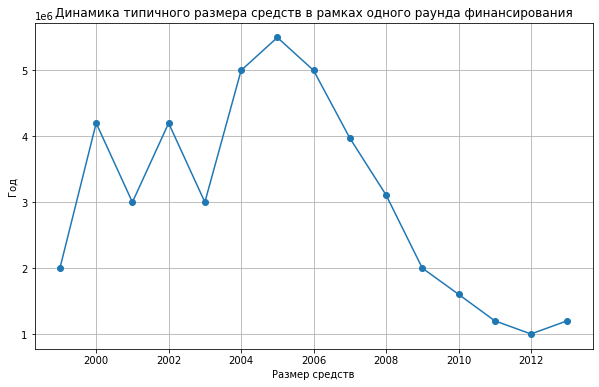

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    summary_filtered['year'], 
    summary_filtered['typ_raised'], 
    marker='o'
)

plt.title('Динамика типичного размера средств в рамках одного раунда финансирования')
plt.xlabel('Размер средств')
plt.ylabel('Год')
plt.grid()

plt.show()

Типичным размером считаем медиану `raised_amount`. 
После отбора лет с >50 раундов максимум типичного размера пришёлся на 2005 год. В 2013 году наблюдались рост числа раундов и увеличение медианного размера по сравнению с 2012м.


### Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

- Оцените, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделите все компании на несколько групп по количеству сотрудников и оцените среднюю долю сотрудников без информации об образовании в каждой из групп. Обоснуйте выбранные границы групп.
- Оцените, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

In [25]:
# Берём уникальные person_id из education как "есть образование"
edu_persons = set(education['person_id'].dropna().astype('Int64'))

# Оставляем сотрудников с известной компанией
ppl = people[['id', 'company_id']].dropna(subset=['company_id']).copy()

# Флаг наличия сведений об образовании
ppl['has_edu_info'] = ppl['id'].isin(edu_persons)

Теперь построим на уровне компаний -- коичество сотрудников, есть ли у них образование и тд.

In [26]:
company_agg = (
    ppl.groupby('company_id').agg(emp_total=('id', 'count'), emp_with_info=('has_edu_info', 'sum')).reset_index()
)

company_agg['emp_no_info'] = company_agg['emp_total'] - company_agg['emp_with_info']
company_agg['share_no_info'] = company_agg['emp_no_info'] / company_agg['emp_total']

In [27]:
company_agg.head()

,company_id,emp_total,emp_with_info,emp_no_info,share_no_info
0,1,2,1,1,0.500000
1,2,1,1,0,0.000000
2,3,3,2,1,0.333333
3,4,13,12,1,0.076923
4,5,61,45,16,0.262295


Разобьем компании на группы по числу сотрудников.

In [28]:
company_agg = company_agg[company_agg['emp_total'] >= 1].copy()

company_agg['size_group'] = pd.cut(
    company_agg['emp_total'],
    bins = [1, 5, 10, 100, 200, float('inf')],
    labels = ['микро', 'малые', 'средние', 'крупные', 'огромные'],
    right = True,
    include_lowest = True
)

In [29]:
group_sum = (
    company_agg.groupby('size_group')
               .agg(companies=('company_id', 'nunique'),
                    avg_share_no_info=('share_no_info', 'mean'),
                    employees=('emp_total', 'sum'))
               .reset_index()
               .sort_values('size_group')
)

In [30]:
group_sum

,size_group,companies,avg_share_no_info,employees
0,микро,22434,0.465075,29283
1,малые,368,0.531828,2664
2,средние,117,0.431900,2136
3,крупные,2,0.267391,288
4,огромные,1,0.311475,244


<Figure size 720x432 with 0 Axes>

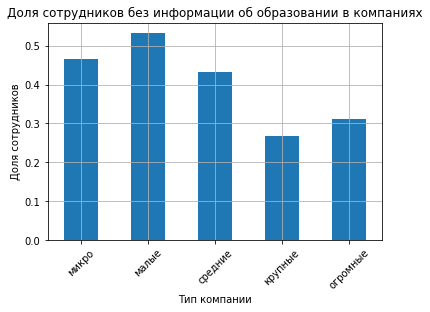

In [31]:
plt.figure(figsize=(10, 6))

group_sum.plot(
    x='size_group',
    y='avg_share_no_info',
    kind='bar',
    rot=45,
    legend=False,
    title=f'Доля сотрудников без информации об образовании в компаниях'
)

plt.xlabel('Тип компании')
plt.ylabel('Доля сотрудников')
plt.grid()

plt.show()

По графику видно, что с ростом размера компании доля сотрудников без сведений об образовании в среднем снижается: максимум у малых и микро, минимумы -- у крупных. Небольшой отскок у огромных вероятнее всего связан с малым числом компаний в этой группе, поэтому интерпретировать стоит осторожно.

Мы оцениваем наличие сведений как наличие записи в `education`.
Средняя доля сотрудников без сведений по группам размера (1–5, 6–10, 11–100, 101–200, 200+) отображена на графике: чем больше компания, тем ниже доля NaN. Границы выбраны так, чтобы группы не пустели при текущем покрытии, а такде как практичные ступени роста компании.

Да, для выполнения задания можно учесть `degrees`, если мы хотим максимально полно оценить количество сотрудников с образованием (бывают случаи, когда у сотрудника есть степень образования, но графа `education` пуста). Однаков, есть ряд минусов: изменится смысл метрики; тяжело сопоставить полноту данных, ведь `degrees` мы имеем тип/специальность, а в `education` -- название/дата.

### Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.

- Установите, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
- Оцените, можно ли использовать столбцы с именем `network_username` для объединения данных.

Ключ `network_username` не подходит для объединения, как основной ключ, и вот почему:
 - В первую очередь, в разных таблица данный ключ обозначает разное: напрмер, в таблице `company_and_rounds` он обозначает код компании, а в `people` -- код человека.

In [32]:
# people
people_missing = people['network_username'].isna().sum()
people_total = len(people)
people_share = people_missing / people_total
people_nunique = people['network_username'].dropna().nunique()
people_dup_rows_cnt = people_total - people_missing - people_nunique   

# company_and_rounds
car_missing = company_and_rounds['network_username'].isna().sum()
car_total = len(company_and_rounds)
car_share = car_missing / car_total
car_nunique = company_and_rounds['network_username'].dropna().nunique()
car_dup_rows_cnt = car_total - car_missing - car_nunique

In [33]:
# Таблица в итоге
summary = pd.DataFrame({
    'dataset': ['people', 'company_and_rounds'],
    'rows_total': [people_total, car_total],
    'missing_cnt': [people_missing, car_missing],
    'missing_share': [people_share, car_share],
    'nunique_nonnull': [people_nunique, car_nunique],
    'dup_rows_cnt': [people_dup_rows_cnt, car_dup_rows_cnt]
})

In [34]:
summary

,dataset,rows_total,missing_cnt,missing_share,nunique_nonnull,dup_rows_cnt
0,people,226709,187842,0.828560,38421,446
1,company_and_rounds,217774,122240,0.561316,79571,15963


 - Ну и конечно же, огромное количество пропусков и дублей, что препятствует грамотному объединению.

Суммируя, видно, что в качестве первичного ключа `network_username` не подходит, однако его можно использовать как дополнительный ключ для более точного объединения.


### Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.

- Любым удобным способом приведите данные в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. Обратите внимание на структуру датасета, порядок и названия столбцов, проанализируйте значения.

По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

- Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовьте данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.

In [ ]:
# Делаем отдельную таблицу по компаниям: 1 строка = 1 компания
company_cols = ['company_id', 'name', 'category_code', 'status',
                'founded_at', 'closed_at', 'domain',
                'network_username', 'country_code',
                'investment_rounds', 'funding_rounds',
                'funding_total', 'milestones']

# Сортируем так, чтобы у строк с максимальным числом заполненных полей был приоритет,
# затем берём первую запись по company_id
df_company = (
    company_and_rounds[company_cols]
    .assign(_filled=lambda x: x.notna().sum(axis=1))
    .sort_values('_filled', ascending=False)
    .drop_duplicates(subset=['company_id'], keep='first')
    .drop(columns='_filled')
    .reset_index(drop=True)
)

print('Уникальных company_id:', company_and_rounds['company_id'].nunique())
print('Строк в df_company:', len(df_company))


In [ ]:
df_company.head()

In [37]:
# Делаем отдельную таблицу по раундам инвестирования
company_and_rounds['funded_year'] = company_and_rounds['funded_at'].dt.year

df_rounds = company_and_rounds[['company_id', 'raised_amount', 'funding_round_id',
                                'funded_at', 'funding_round_type', 'pre_money_valuation',
                                'participants', 'is_first_round',
                                'is_last_round', 'funded_year']]

In [38]:
# Смотрим пропуски
display(df_rounds[df_rounds['funding_round_type'].isna()].head())

,company_id,raised_amount,funding_round_id,funded_at,funding_round_type,pre_money_valuation,participants,is_first_round,is_last_round,funded_year
3,10,NaN,<NA>,NaT,NaN,NaN,<NA>,<NA>,NaN,NaN
4,100,NaN,<NA>,NaT,NaN,NaN,<NA>,<NA>,NaN,NaN
5,10000,NaN,<NA>,NaT,NaN,NaN,<NA>,<NA>,NaN,NaN
6,10001,NaN,<NA>,NaT,NaN,NaN,<NA>,<NA>,NaN,NaN
7,10002,NaN,<NA>,NaT,NaN,NaN,<NA>,<NA>,NaN,NaN


In [39]:
# Убираем пропуски по колонке
df_rounds = df_rounds.dropna(subset=['funding_round_type'])

In [40]:
df_rounds.head()

,company_id,raised_amount,funding_round_id,funded_at,funding_round_type,pre_money_valuation,participants,is_first_round,is_last_round,funded_year
0,1,5250000.0,888,2005-10-01,series-a,0.0,2,0,1.0,2005.0
1,1,9500000.0,889,2007-01-01,series-b,0.0,3,0,0.0,2007.0
2,1,25000000.0,2312,2008-05-19,series-c+,0.0,4,1,0.0,2008.0
15,1001,5000000.0,1644,2008-02-26,series-a,0.0,3,1,1.0,2008.0
20,10014,0.0,6682,2008-09-01,angel,0.0,1,1,1.0,2008.0


In [41]:
df_company.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0
3,10,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0,0,0.0,0.0
4,100,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0,0,0.0,4.0
5,10000,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0,0,0.0,0.0
6,10001,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0,0,0.0,0.0


### Промежуточный вывод

Исходный `company_and_rounds` был разделён на две таблицы:
- `df_company` — одна строка на компанию (~196 тыс. строк, по числу уникальных `company_id`);
- `df_rounds` — одна строка на раунд финансирования, с удалёнными пропусками по `funding_round_type`.

Общий ключ `company_id` позволяет легко объединять таблицы при необходимости. Массовые пропуски в исходных данных объяснялись тем, что карточки компаний и раунды финансирования хранились в одном датафрейме вперемешку: при разделении по смысловому признаку пропуски в компании-ориентированных полях исчезают.



## Исследовательский анализ объединённых таблиц


### Объединение данных

Объедините данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

В качестве основы для объединённой таблицы возьмите данные из обработанного датасета `company_and_rounds.csv` — выберите только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. В результирующей таблице должно получиться порядка 40 тысяч компаний.

Проверьте полноту и корректность получившейся таблицы. Далее работайте только с этими данными.

In [42]:
# Составим базу интересующих компаний

df_company = df_company[
    (df_company['funding_rounds'] > 0) |
    (df_company['investment_rounds'] > 0) |
    (df_company['status'] == 'acquired')
]

In [43]:
# Считаем, сколько раз компании получали инвестиции или финансировались, а также за сколько в последний раз была куплена компания

acq_target_cnt = acquisition.groupby('acquired_company_id', as_index=False).agg(
    acq_times_as_target=('id', 'count')
).rename(columns={'acquired_company_id': 'company_id'})


acq_buyer_cnt = acquisition.groupby('acquiring_company_id', as_index=False).agg(
    acq_times_as_buyer=('id', 'count')
).rename(columns={'acquiring_company_id': 'company_id'})

acq_price = (acquisition.sort_values('acquired_at').drop_duplicates('acquired_company_id', keep='last')
               [['acquired_company_id', 'price_amount']].rename(columns={
                   'acquired_company_id': 'company_id',
                   'price_amount': 'price'
               })
)

In [44]:
# Объединяем данные

df_company = df_company.merge(
    acq_target_cnt, on='company_id', how='left'
).merge(
    acq_buyer_cnt, on='company_id', how='left'
).merge(
    acq_price, on='company_id', how='left'
)

In [45]:
for c in ['acq_times_as_target', 'acq_times_as_buyer']:
    if c in df_company.columns:
        df_company[c] = df_company[c].fillna(0).astype('Int64')

In [46]:
df_company.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,acq_times_as_target,acq_times_as_buyer,price
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0,0,0,<NA>
1,10,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0,0,0.0,0.0,1,0,20000000
2,100,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0,0,0.0,4.0,1,0,0
3,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,1,5000000.0,3.0,1,0,47500000
4,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,1,0.0,4.0,1,1,0


In [47]:
df_company.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40747 entries, 0 to 40746
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company_id           40747 non-null  Int64         
 1   name                 40747 non-null  object        
 2   category_code        35315 non-null  category      
 3   status               40747 non-null  category      
 4   founded_at           27807 non-null  datetime64[ns]
 5   closed_at            2128 non-null   datetime64[ns]
 6   domain               35754 non-null  object        
 7   network_username     20850 non-null  object        
 8   country_code         34742 non-null  category      
 9   investment_rounds    40747 non-null  Int64         
 10  funding_rounds       40747 non-null  Int64         
 11  funding_total        40747 non-null  float64       
 12  milestones           40747 non-null  float64       
 13  acq_times_as_target  40747 non-

### Промежуточный вывод

Объединённая таблица содержит порядка 40 тыс. компаний, у которых есть хотя бы один раунд финансирования/инвестиций или статус `acquired`. К ним подтянуты агрегаты из `acquisition`:
- `acq_times_as_target` — сколько раз компания выступала объектом покупки;
- `acq_times_as_buyer` — сколько раз компания выступала покупателем;
- `price` — цена последней сделки покупки.

Именно эта таблица используется для дальнейшего анализа: распределения `funding_total`, поиска аномальных сделок по 0–1 доллару, сравнения категорий по цене и разбросу, а также связи числа раундов финансирования со статусом.



### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

- По предобработанному столбцу `funding_total` графическим способом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.
- В процессе расчёта значений обратите внимание, например, на показатели, возвращаемые методом `.describe()`, — объясните их. Применимы ли к таким данным обычные способы нахождения типичных значений?

In [48]:
df_company['funding_total'].describe()

count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+05
75%      5.650650e+06
max      5.700000e+09
Name: funding_total, dtype: float64

Видно, что существует сильный разброс. Будет удобнее смотреть на медиану и межквартальный размах.

Помимо этого мы имеем дело с большими значениями, поэтому на графиках лучше будет использовать логарифмическую шкалу.

In [49]:
# Вызываем библиотеку
import numpy as np

df_netzero = df_company[df_company['funding_total'] > 0].copy()
df_netzero['log_funding'] = np.log10(df_netzero['funding_total'])

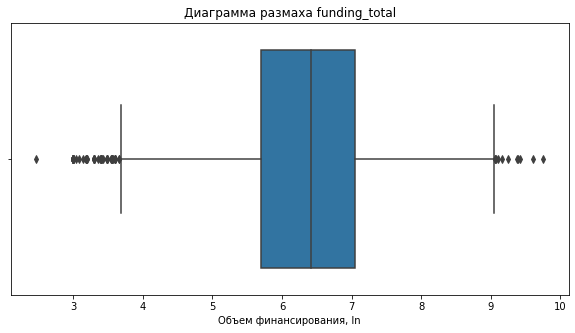

In [50]:
# Построим диаграмму размаха 

plt.figure(figsize=(10, 5))

sns.boxplot(x=df_netzero['log_funding'])

plt.title('Диаграмма размаха funding_total')
plt.xlabel('Объем финансирования, ln')

plt.show()

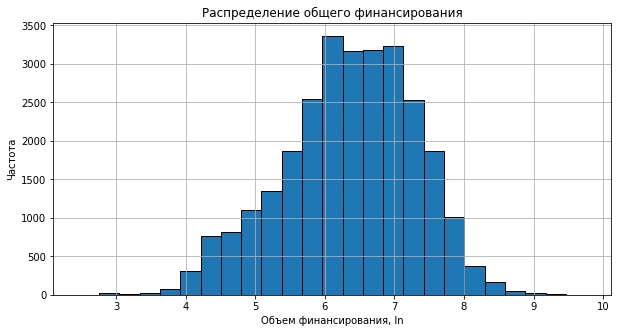

In [ ]:
# Построим гистограмму 
plt.figure(figsize=(10, 5))

df_netzero['log_funding'].plot(
    kind='hist', 
    bins=25, 
    edgecolor='black',
    rot=0, 
)

plt.title('Распределение общего финансирования')
plt.xlabel('Объем финансирования, ln')
plt.ylabel('Частота')
plt.grid()

plt.show()

Таким образом, для анализа `funding_total` были построена гистограмма и диаграмма размаха по логарифму значений. По графиками видно, что:
 - типичный объем финансирования: от `10^6` до `10^7` долларов;
 - заметно много выбивающихся значений, причем с достаточно большим разбросом;
 - метод `describe()` показывает сильную асимметрию: медиана очень сильно отличается от среднего, что указывает на наличие экстремальных значений.

Суммируя, обычные способы (например, среднее) неприменимы из-за скошенного распределения, в то время как медиана и логарифмическое преобразование дают более устойчивую картину для анализа типичных величин.


### Куплены забесплатно?

- Исследуйте компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитайте аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют.

In [ ]:
# Отфильтруем компании под заданные метрики

cheap_sold = df_company[
    (df_company['price'].isin([0, 1])) & (df_company['funding_total'] > 0)
]

In [53]:
# Cчитаем границы выбросов 

Q1 = cheap_sold["funding_total"].quantile(0.25)
Q3 = cheap_sold["funding_total"].quantile(0.75)

IQR = Q3 - Q1

In [54]:
IQR

13400000.0

In [55]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [56]:
print("Нижняя граница выбросов:", lower)
print("Верхняя граница выбросов:", upper)

Нижняя граница выбросов: -18100000.0
Верхняя граница выбросов: 35500000.0


In [57]:
# Перцентили, к которым ближе всего попадают границы

lower_percentile = (cheap_sold['funding_total'] <= lower).mean() * 100
upper_percentile = (cheap_sold['funding_total'] <= upper).mean() * 100

In [58]:
print(f'Нижняя граница выбросов: {lower}')
print(f'Верхняя граница выбросов: {upper}')
print(f'Нижняя граница ≈ {lower_percentile:.2f} перцентиль')
print(f'Верхняя граница ≈ {upper_percentile:.2f} перцентиль')

Нижняя граница выбросов: -18100000.0
Верхняя граница выбросов: 35500000.0
Нижняя граница ≈ 0.00 перцентиль
Верхняя граница ≈ 91.12 перцентиль


Анализ показал, что среди компаний, проданных за 0 или 1 доллар при ненулевом объёме финансирования, нижняя граница выбросов по методу межквартильного размаха составила –18.1 млн долларов, что означает, что фактических выбросов снизу и нет. Верхняя граница равна 35.5 млн долларов и соответствует примерно 91 перцентилю распределения. 


### Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделите категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

Объясните, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.

In [ ]:
# Оставляем только те компании, у которых есть цена и категория

df_valid = df_company.dropna(subset=['price', 'category_code'])

In [60]:
# Группируем по категориям

agg = df_valid.groupby('category_code')['price'].agg(['median', 'std', 'count']).reset_index()

In [61]:
# Отсеиваем категории с очень редкими сделками

agg = agg[agg['count'] >= 10]

In [62]:
# Топ-5 по медиане 

top_median = agg.sort_values('median', ascending=False).head(5)

In [63]:
top_median

,category_code,median,std,count
19,manufacturing,72000000.0,9.696580e+08,29
16,hospitality,12500000.0,6.514494e+08,11
3,biotech,12250000.0,1.543653e+09,452
11,finance,600000.0,7.960985e+08,40
0,advertising,0.0,2.767470e+08,307


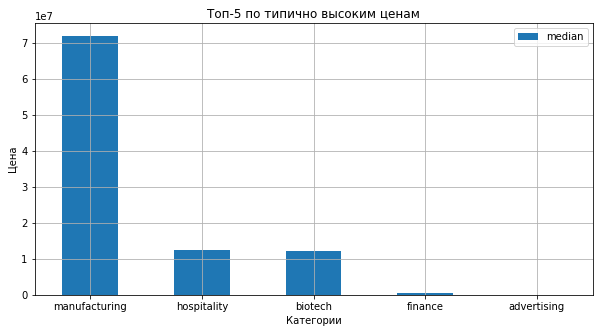

In [64]:
top_median.plot(
    x='category_code',
    y='median',
    kind='bar',
    title=f'Топ-5 по типично высоким ценам',
    ylabel='Цена',
    xlabel='Категории',
    rot=0,
    figsize=(10, 5)
)

plt.grid()

plt.show()

In [65]:
# Топ-5 по стандартному отклонению

top_spread = agg.sort_values('std', ascending=False).head(5)

In [66]:
top_spread

,category_code,median,std,count
31,public_relations,0.0,4.115162e+09,213
3,biotech,12250000.0,1.543653e+09,452
15,health,0.0,1.249084e+09,27
28,other,0.0,1.097271e+09,308
19,manufacturing,72000000.0,9.696580e+08,29


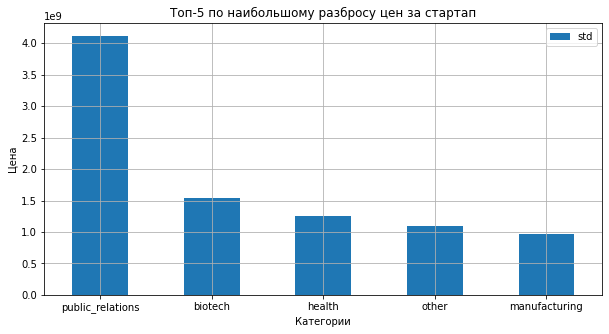

In [67]:
top_spread.plot(
    x='category_code',
    y='std',
    kind='bar',
    title=f'Топ-5 по наибольшому разбросу цен за стартап',
    ylabel='Цена',
    xlabel='Категории',
    rot=0,
    figsize=(10, 5)
)

plt.grid()

plt.show()

### Промежуточный вывод

- **Типично высокие цены** (медиана): `manufacturing`, `biotech`, `hospitality`. В этих сегментах типичная сделка стоит значительно дороже среднего по рынку.
- **Наибольший разброс цен** (стандартное отклонение): `public_relations`, `biotech`, `health`, `other`. Это сегменты высокого риска: рядом с крупными сделками встречаются и сравнительно дешёвые.
- `biotech` попадает в оба топа — категория одновременно с высоким типичным чеком и большим разбросом, что делает её интересной для крупных инвесторов с высокой толерантностью к риску.


`Почему взяли именно топ-5 категорий?`
Такой размер выборки позволяет поймать баланс между детализацией и информативностью: меньше категорий -- теряется полнота картины, больше категорий -- информация становится перегруженной. Также, в топ-5 попадают наиболее ярко выраженные категории.

`Почему брали медиану для типично высокой цены?`
В отличие от среднего, медиана устойчива к выбросам: в сделках со стартапами наблюдается большой разброс данных, поэтому, среднее искажается. 

`Почему брали стандартное отклонение для разброса?`
Это простая и понятная метрика, которая показывает, насколько сильно колеблются цены в пределах одной категории. Для заказчиков это хороший показатель уровня риска.


### Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
- Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.

In [ ]:
# Оставляем только те стартапы, где есть данные о количестве раундов и статусе

df_valid = df_company.dropna(subset=['funding_rounds', 'status'])

In [69]:
agg = df_valid.groupby('status')['funding_rounds'].agg(['mean', 'median', 'count']).reset_index()

In [70]:
agg.describe()

,mean,median,count
count,4.000000,4.00,4.000000
mean,1.340503,0.75,10186.750000
std,0.593013,0.50,12872.651096
min,0.523526,0.00,640.000000
25%,1.166971,0.75,1729.000000
50%,1.452056,1.00,5743.000000
75%,1.625587,1.00,14200.750000
max,1.934375,1.00,28621.000000


In [71]:
agg.sort_values(by='mean', ascending=False)

,status,mean,median,count
2,ipo,1.934375,1.0,640
3,operating,1.522658,1.0,28621
1,closed,1.381453,1.0,2092
0,acquired,0.523526,0.0,9394


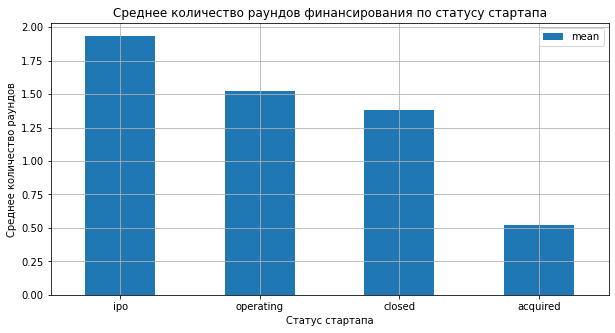

In [72]:
agg.sort_values(by='mean', ascending=False).plot(
    x='status',
    y='mean',
    kind='bar',
    title=f'Среднее количество раундов финансирования по статусу стартапа',
    ylabel='Среднее количество раундов',
    xlabel='Статус стартапа',
    rot=0,
    figsize=(10, 5)
)

plt.grid()

plt.show()

Среднее количество раундов финансирования заметно различается для разных статусов стартапов. Компании, которые были куплены, обычно проходят меньше всего раундов. Действующие стартапы и те, что вышли на IPO, в среднем имеют два и более раунда, поскольку им необходимо привлекать больше ресурсов для роста. Закрытые стартапы чаще всего успевают пройти примерно полтора раунда, но не дотягивают до стабильного развития. 

Таким образом, можно сделать вывод, что покупка стартапа чаще происходит на ранних стадиях, в то время как длительное существование требует большего числа раундов финансирования.


## Итоговый вывод и рекомендации

### Общий обзор проделанной работы

В рамках исследования были проанализированы данные о стартапах, их раундах финансирования, сделках по покупке компаний и информации о сотрудниках. Проведена предобработка: нормализация столбцов, устранение дубликатов, приведение типов, разделение данных на таблицы по компаниям и по раундам. Построены сводные таблицы и графики, исследованы типичные размеры финансирования, выбросы, а также зависимость цены и числа раундов от категорий и статуса компаний.

### Главные выводы

- Данные о компаниях и раундах оказались сильно загрязненными, но удалось выделить корректные таблицы по примерно 40 тыс. компаний.

- Финансирование имеет крайне скошенное распределение.

- Найдены компании, проданные за символические суммы при наличии существенного финансирования -- такие сделки выглядят аномальными.

- Категории с типично высокими ценами -- manufacturing, biotech, hospitality; с наибольшим разбросом -- public_relations, biotech, health, other.

- По числу раундов финансирования видно, что стартапы, вышедшие на IPO, проходят больше всего стадий, а приобретённые продаются с наименьшим числом раундов.

### Рекомендации

- Для анализа успешности сделок лучше опираться на медианные значения и использовать логарифмические преобразования.

- Сделки по нулевой цене стоит отдельно маркировать и выделять.

- Для инвесторов перспективны категории с высокими медианными ценами, но важно учитывать риски, связанные с разбросом цен.

- Для оценки человеческого капитала компании важно дополнительно учитывать данные об образовании сотрудников, но с поправкой на неполноту информации в датасетах.